In [ ]:
!git clone https://github.com/jjeong3150/AIFFEL_final_pjt_book-recommendation-agent

In [ ]:
%run /content/AIFFEL_final_project_peekabook/research/src/state/state_v2.ipynb

In [ ]:
!pip install -qU langgraph langchain langchain-core langchain-community langchain-openai langchain-google-genai langchain-naver langchain-chroma chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.4/245.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71

In [ ]:
from google.colab import userdata

In [ ]:
import os
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
# os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
os.environ["CLOVASTUDIO_API_KEY"] = userdata.get('CLOVASTUDIO_API_KEY')

## Config

In [ ]:
"""환경 설정."""

from __future__ import annotations

import os


class Config:
    # LLM 설정
    LLM_MODEL: str = os.getenv("LLM_MODEL", "gpt-4o-mini")
    LLM_TEMPERATURE: float = float(os.getenv("LLM_TEMPERATURE", "0.7"))
    OPENAI_API_KEY: str = os.getenv("OPENAI_API_KEY", "")

    # ChromaDB 설정
    CHROMA_DB_PATH: str = os.getenv("CHROMA_DB_PATH", "./chroma_db")

    # 프로파일링 설정
    MAX_SLOT_RETRIES: int = 3                # 슬롯 재질문 최대 횟수
    SIMILARITY_THRESHOLD: float = 0.5        # 유사 프로파일 검색 임계값
    CONFIDENCE_THRESHOLD: float = 0.6        # 슬롯 filled 판정 신뢰도 임계값
    SIMILAR_SEARCH_K: int = 3                # 유사 프로파일 검색 개수
    LINK_CANDIDATE_K: int = 5                # 링크 후보 검색 개수

## Models

In [ ]:
# """Data models for user profile and book curation system."""

# from __future__ import annotations

# from datetime import datetime
# from enum import Enum
# from typing import Optional

# from pydantic import BaseModel, Field


# # ──────────────────────────────────────────────
# # Enums
# # ──────────────────────────────────────────────
# class SlotStatus(str, Enum):
#     EMPTY = "empty"
#     FILLED = "filled"
#     UNCLEAR = "unclear"


# class Phase(str, Enum):
#     SLOT_FILLING = "slot_filling"
#     SIMILAR_SEARCH = "similar_search"
#     MATCH_CONFIRM = "match_confirm"
#     BOOK_EXPERIENCE = "book_experience"
#     SUMMARY = "summary"
#     REFLECTION = "reflection"
#     DONE = "done"


# SLOT_NAMES: list[str] = [
#     "reading_goal",
#     "preferred_genre",
#     "reading_style",
#     "difficulty_level",
#     "current_context",
# ]

# SLOT_DESCRIPTIONS: dict[str, str] = {
#     "reading_goal": "사용자가 현재 왜 책을 읽고 싶어하는지 (동기/목적)",
#     "preferred_genre": "사용자가 현재 관심을 가지는 장르나 분야",
#     "reading_style": "사용자가 어떤 스타일의 독서를 선호하는지 (깊이, 속도, 형식 등)",
#     "difficulty_level": "사용자가 선호하는 책의 난이도",
#     "current_context": "사용자의 현재 상황이나 감정 상태",
# }


# # ──────────────────────────────────────────────
# # Profile Slot
# # ──────────────────────────────────────────────
# class ProfileSlot(BaseModel):
#     value: str = ""
#     status: SlotStatus = SlotStatus.EMPTY
#     retry_count: int = 0

#     MAX_RETRIES: int = 3


# # ──────────────────────────────────────────────
# # User Profile
# # ──────────────────────────────────────────────
# class UserProfile(BaseModel):
#     reading_goal: ProfileSlot = Field(default_factory=ProfileSlot)
#     preferred_genre: ProfileSlot = Field(default_factory=ProfileSlot)
#     reading_style: ProfileSlot = Field(default_factory=ProfileSlot)
#     difficulty_level: ProfileSlot = Field(default_factory=ProfileSlot)
#     current_context: ProfileSlot = Field(default_factory=ProfileSlot)

#     def get_slot(self, name: str) -> ProfileSlot:
#         return getattr(self, name)

#     def set_slot(self, name: str, slot: ProfileSlot) -> None:
#         setattr(self, name, slot)

#     def filled_slots(self) -> list[str]:
#         return [s for s in SLOT_NAMES if self.get_slot(s).status == SlotStatus.FILLED]

#     def empty_slots(self) -> list[str]:
#         return [
#             s
#             for s in SLOT_NAMES
#             if self.get_slot(s).status == SlotStatus.EMPTY
#         ]

#     def all_filled_or_unclear(self) -> bool:
#         """모든 슬롯이 filled 이거나 unclear(재시도 초과)인지 확인."""
#         return all(
#             self.get_slot(s).status in (SlotStatus.FILLED, SlotStatus.UNCLEAR)
#             for s in SLOT_NAMES
#         )

#     def reading_goal_filled(self) -> bool:
#         """reading_goal이 filled인지 확인."""
#         return self.reading_goal.status == SlotStatus.FILLED

#     def to_embedding_text(self) -> str:
#         """ChromaDB 임베딩용 텍스트 생성."""
#         parts = []
#         for name in SLOT_NAMES:
#             slot = self.get_slot(name)
#             if slot.value:
#                 parts.append(f"{SLOT_DESCRIPTIONS[name]}: {slot.value}")
#         return " | ".join(parts)

#     def to_display_dict(self) -> dict:
#         """프로필 표시용 딕셔너리."""
#         return {
#             name: {
#                 "value": self.get_slot(name).value,
#                 "status": self.get_slot(name).status.value,
#             }
#             for name in SLOT_NAMES
#         }

#     @classmethod
#     def from_dict(cls, data: dict) -> "UserProfile":
#         """딕셔너리(ChromaDB 저장 형태)로부터 UserProfile을 재구성한다."""
#         profile = cls()
#         for name in SLOT_NAMES:
#             if name in data:
#                 slot_data = data[name]
#                 slot = ProfileSlot(
#                     value=slot_data.get("value", ""),
#                     status=SlotStatus(slot_data.get("status", "empty")),
#                     retry_count=slot_data.get("retry_count", 0),
#                 )
#                 profile.set_slot(name, slot)
#         return profile


# # ──────────────────────────────────────────────
# # Book Experience
# # ──────────────────────────────────────────────
# class BookExperience(BaseModel):
#     book_name: str
#     impression: str
#     context: str = ""  # 어떤 맥락에서 읽었는지


# # ──────────────────────────────────────────────
# # Session Memory (ChromaDB 저장 단위)
# # ──────────────────────────────────────────────
# class SessionMemory(BaseModel):
#     session_id: str
#     timestamp: str = Field(default_factory=lambda: datetime.now().isoformat())
#     profile: UserProfile = Field(default_factory=UserProfile)
#     book_experiences: list[BookExperience] = Field(default_factory=list)
#     summary: str = ""
#     reflection: str = ""
#     linked_session_ids: list[str] = Field(default_factory=list)


# # ──────────────────────────────────────────────
# # Link (a-mem 스타일)
# # ──────────────────────────────────────────────
# class MemoryLink(BaseModel):
#     source_session_id: str
#     target_session_id: str
#     link_reason: str
#     strength: float = 0.0  # 0.0 ~ 1.0

## DB

In [ ]:
"""ChromaDB operations for session memory storage, retrieval, and linking."""

from __future__ import annotations

import json
from typing import Any, Optional

import chromadb

#from models import MemoryLink, SessionMemory, UserProfile


class MemoryStore:
    """ChromaDB 기반 세션 메모리 저장소.

    Collections:
      - session_memories : 세션별 프로파일 + summary + reflection 저장
      - memory_links     : 세션 간 연결 정보 저장
    """

    def __init__(self, persist_directory: str = "./chroma_db"):
        self.client = chromadb.PersistentClient(path=persist_directory)
        self.sessions = self.client.get_or_create_collection(
            name="session_memories",
            metadata={"hnsw:space": "cosine"},
        )
        self.links = self.client.get_or_create_collection(
            name="memory_links",
            metadata={"hnsw:space": "cosine"},
        )

    # ──────────────────────────────────────────
    # 세션 메모리 저장 / 업데이트
    # ──────────────────────────────────────────
    def save_session(self, memory: SessionMemory) -> None:
        """세션 메모리를 ChromaDB에 저장(upsert)한다."""
        embedding_text = self._build_embedding_text(memory)
        metadata = {
            "session_id": memory.session_id,
            "timestamp": memory.timestamp,
            "summary": memory.summary,
            "reflection": memory.reflection,
            "profile_json": memory.profile.model_dump_json(),
            "experiences_json": json.dumps(
                [e.model_dump() for e in memory.book_experiences], ensure_ascii=False
            ),
            "linked_ids": json.dumps(memory.linked_session_ids),
        }
        self.sessions.upsert(
            ids=[memory.session_id],
            documents=[embedding_text],
            metadatas=[metadata],
        )

    # ──────────────────────────────────────────
    # 유사 프로파일 검색
    # ──────────────────────────────────────────
    def search_similar_profiles(
        self,
        profile: UserProfile,
        k: int = 3,
        exclude_session_id: Optional[str] = None,
    ) -> list[dict[str, Any]]:
        """현재 프로파일과 유사한 이전 세션 메모리를 검색한다."""
        query_text = profile.to_embedding_text()
        if not query_text.strip():
            return []

        results = self.sessions.query(
            query_texts=[query_text],
            n_results=k,
        )

        similar = []
        if results and results["ids"] and results["ids"][0]:
            for i, sid in enumerate(results["ids"][0]):
                if exclude_session_id and sid == exclude_session_id:
                    continue
                meta = results["metadatas"][0][i]
                distance = results["distances"][0][i] if results["distances"] else None
                similar.append(
                    {
                        "session_id": sid,
                        "summary": meta.get("summary", ""),
                        "reflection": meta.get("reflection", ""),
                        "profile": json.loads(meta.get("profile_json", "{}")),
                        "experiences": json.loads(meta.get("experiences_json", "[]")),
                        "distance": distance,
                        "timestamp": meta.get("timestamp", ""),
                    }
                )
        return similar

    # ──────────────────────────────────────────
    # summary 기반 유사 메모리 검색 (reflection용)
    # ──────────────────────────────────────────
    def search_by_summary(
        self,
        summary: str,
        k: int = 5,
        exclude_session_id: Optional[str] = None,
    ) -> list[dict[str, Any]]:
        """summary 텍스트를 기준으로 유사한 세션 메모리를 검색한다."""
        if not summary.strip():
            return []

        results = self.sessions.query(
            query_texts=[summary],
            n_results=k,
        )

        similar = []
        if results and results["ids"] and results["ids"][0]:
            for i, sid in enumerate(results["ids"][0]):
                if exclude_session_id and sid == exclude_session_id:
                    continue
                meta = results["metadatas"][0][i]
                distance = results["distances"][0][i] if results["distances"] else None
                similar.append(
                    {
                        "session_id": sid,
                        "summary": meta.get("summary", ""),
                        "reflection": meta.get("reflection", ""),
                        "profile": json.loads(meta.get("profile_json", "{}")),
                        "experiences": json.loads(meta.get("experiences_json", "[]")),
                        "distance": distance,
                        "timestamp": meta.get("timestamp", ""),
                    }
                )
        return similar

    # ──────────────────────────────────────────
    # 링크 저장 / 조회
    # ──────────────────────────────────────────
    def save_link(self, link: MemoryLink) -> None:
        """두 세션 간의 링크를 저장한다."""
        link_id = f"{link.source_session_id}___{link.target_session_id}"
        self.links.upsert(
            ids=[link_id],
            documents=[link.link_reason],
            metadatas=[
                {
                    "source_id": link.source_session_id,
                    "target_id": link.target_session_id,
                    "strength": link.strength,
                    "reason": link.link_reason,
                }
            ],
        )

    def get_linked_sessions(self, session_id: str) -> list[dict[str, Any]]:
        """특정 세션의 1-hop 연결된 세션 메모리들을 조회한다."""
        # source → target 방향 링크 조회
        try:
            results = self.links.get(
                where={"source_id": session_id},
            )
        except Exception:
            results = {"ids": [], "metadatas": []}

        linked_ids = set()
        if results and results["metadatas"]:
            for meta in results["metadatas"]:
                linked_ids.add(meta["target_id"])

        # target → source 방향도 조회 (양방향)
        #try:
        #    results2 = self.links.get(
        #        where={"target_id": session_id},
        #    )
        #except Exception:
        #    results2 = {"ids": [], "metadatas": []}

        #if results2 and results2["metadatas"]:
        #    for meta in results2["metadatas"]:
        #        linked_ids.add(meta["source_id"])

        # 연결된 세션 메모리 가져오기
        linked_memories = []
        for lid in linked_ids:
            try:
                session_result = self.sessions.get(ids=[lid])
                if session_result and session_result["metadatas"]:
                    meta = session_result["metadatas"][0]
                    linked_memories.append(
                        {
                            "session_id": lid,
                            "summary": meta.get("summary", ""),
                            "reflection": meta.get("reflection", ""),
                            "profile": json.loads(meta.get("profile_json", "{}")),
                            "experiences": json.loads(meta.get("experiences_json", "[]")),
                            "timestamp": meta.get("timestamp", ""),
                        }
                    )
            except Exception:
                continue

        return linked_memories

    # ──────────────────────────────────────────
    # 세션 메모리 조회
    # ──────────────────────────────────────────
    def get_session(self, session_id: str) -> Optional[dict[str, Any]]:
        """특정 세션 메모리를 조회한다."""
        try:
            result = self.sessions.get(ids=[session_id])
            if result and result["metadatas"] and result["metadatas"][0]:
                meta = result["metadatas"][0]
                return {
                    "session_id": session_id,
                    "summary": meta.get("summary", ""),
                    "reflection": meta.get("reflection", ""),
                    "profile": json.loads(meta.get("profile_json", "{}")),
                    "experiences": json.loads(meta.get("experiences_json", "[]")),
                    "timestamp": meta.get("timestamp", ""),
                }
        except Exception:
            pass
        return None

    # ──────────────────────────────────────────
    # 내부 헬퍼
    # ──────────────────────────────────────────
    def _build_embedding_text(self, memory: SessionMemory) -> str:
        """임베딩용 텍스트를 구성한다."""
        parts = [memory.profile.to_embedding_text()]
        if memory.summary:
            parts.append(f"요약: {memory.summary}")
        if memory.reflection:
            parts.append(f"인사이트: {memory.reflection}")
        for exp in memory.book_experiences:
            parts.append(f"독서경험: {exp.book_name} - {exp.impression}  {exp.context}")
        return " | ".join(parts)


## Utils

In [ ]:
"""LLM call utilities and response parsing."""

from __future__ import annotations

import json
import re
from typing import Any

from langchain_core.language_models import BaseChatModel
from langchain_core.messages import HumanMessage, SystemMessage


async def llm_call(llm: BaseChatModel, prompt: str) -> str:
    """단일 프롬프트 → LLM 호출 → 텍스트 응답 반환."""
    messages = [HumanMessage(content=prompt)]
    response = await llm.ainvoke(messages)
    return response.content.strip()


async def llm_call_with_system(
    llm: BaseChatModel, system: str, user: str
) -> str:
    """시스템 + 사용자 메시지 → LLM 호출."""
    messages = [SystemMessage(content=system), HumanMessage(content=user)]
    response = await llm.ainvoke(messages)
    return response.content.strip()


def parse_json_response(text: str) -> dict[str, Any]:
    """LLM 응답에서 JSON 블록을 추출하여 파싱한다.

    ```json ... ``` 래핑, 여분의 텍스트 등을 처리한다.
    """
    # 1) ```json ... ``` 블록 추출 시도
    match = re.search(r"```(?:json)?\s*\n?(.*?)\n?```", text, re.DOTALL)
    if match:
        text = match.group(1)

    # 2) { } 또는 [ ] 블록만 추출
    match = re.search(r"(\{.*\}|\[.*\])", text, re.DOTALL)
    if match:
        text = match.group(1)

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {}


def format_conversation_context(messages: list, last_n: int = 10) -> str:
    """최근 N개 메시지를 대화 맥락 문자열로 변환."""
    recent = messages[-last_n:] if len(messages) > last_n else messages
    lines = []
    for msg in recent:
        role = getattr(msg, "type", "unknown")
        content = getattr(msg, "content", str(msg))
        if role == "human":
            lines.append(f"사용자: {content}")
        elif role == "ai":
            lines.append(f"큐레이터: {content}")
    return "\n".join(lines)

## State
- state_v2.ipynb로 이관

In [ ]:
# """LangGraph state definition for the book curation system."""

# from __future__ import annotations

# from typing import Annotated, Any, Optional

# from langgraph.graph.message import add_messages
# from typing_extensions import TypedDict

# #from models import BookExperience, MemoryLink, Phase, UserProfile


# class GraphState(TypedDict):
#     """LangGraph 상태 정의.

#     각 그래프 실행(=사용자 1턴)마다 상태가 업데이트되고
#     체크포인터를 통해 영속 저장된다.
#     """

#     # ── 대화 히스토리 ──
#     messages: Annotated[list, add_messages]

#     # ── 세션 메타 ──
#     session_id: str
#     phase: Phase
#     turn_count: int

#     # ── 사용자 프로필 (슬롯 필링) ──
#     user_profile: UserProfile
#     current_slot: Optional[str]  # 현재 질문 대상 슬롯

#     # ── 유사 프로파일 검색 ──
#     similar_profiles: list[dict[str, Any]]
#     matched_profile_id: Optional[str]

#     # ── 독서 경험 ──
#     book_experiences: list[BookExperience]
#     asked_book_experience: bool  # 이전 독서 경험 질문 여부

#     # ── 요약 ──
#     summary: str

#     # ── Reflection & Links ──
#     reflection: str
#     links: list[MemoryLink]

#     # ── AI 응답 (현재 턴의 응답) ──
#     ai_response: str


## Prompts

In [ ]:
"""Prompt templates for the book curation profiling system."""

# ──────────────────────────────────────────────
# 1. 슬롯 필링 질문 생성
# ──────────────────────────────────────────────
SLOT_QUESTION_PROMPT = """\
당신은 친절한 도서 큐레이터입니다.
사용자의 도서 선호 프로파일을 파악하기 위해 자연스러운 질문을 생성해야 합니다.

현재까지 수집된 프로필 정보:
{filled_profile}

이번에 파악해야 할 항목: {slot_name}
항목 설명: {slot_description}

이전 대화 맥락:
{conversation_context}

{retry_instruction}

요구사항:
- 한국어로 작성
- 이미 수집된 정보를 자연스럽게 참조하며 대화를 이어가세요
- 직접적이지 않고 대화체로 물어보세요
- 1~3문장 이내

질문:"""

RETRY_INSTRUCTION_TEMPLATE = """\
주의: 이전에 이 항목에 대해 질문했으나 사용자가 명확한 답변을 하지 않았습니다. (재시도 {retry_count}/{max_retries}회)
다른 각도에서, 더 구체적인 예시를 들어 질문을 재구성하세요."""

# ──────────────────────────────────────────────
# 3. 사용자 응답에서 슬롯 정보 추출
# ──────────────────────────────────────────────
EXTRACT_SLOT_PROMPT = """\
당신은 도서 큐레이션을 위한 정보 추출기입니다.
사용자의 응답에서 아래 항목들에 대한 정보를 추출하세요.

추출 대상 항목:
{target_slots}

사용자 응답: "{user_message}"

대화 맥락:
{conversation_context}

아래 JSON 형식으로 응답하세요. 정보가 없는 항목은 null로 표시합니다:
{{
    "extracted": {{
        "<slot_name>": {{
            "value": "추출된 값 또는 null"
        }}
    }}
}}

JSON 응답:"""

# ──────────────────────────────────────────────
# 4. 유사 프로파일 요약 제시
# ──────────────────────────────────────────────
SIMILAR_PROFILE_PRESENT_PROMPT = """\
이전에 비슷한 맥락에서 도서를 찾으셨던 기록이 있습니다.

이전 프로파일 요약:
{profile_summary}

이 정보를 사용자에게 자연스럽게 설명하고, 이번에도 비슷한 도서를 찾고 있는지 물어보세요.

요구사항:
- 한국어로 작성
- 이전 기록을 간결하게 정리
- 이번에도 같은 종류의 책을 찾는지 yes/no로 답할 수 있게 질문
- 2~4문장 이내

응답:"""

# ──────────────────────────────────────────────
# 5. 매칭 확인 응답 판단
# ──────────────────────────────────────────────
MATCH_CONFIRM_PROMPT = """\
사용자의 응답이 이전 프로파일과 같은 종류의 책을 찾고 있다는 긍정적 답변인지 판단하세요.

사용자 응답: "{user_message}"

아래 JSON 형식으로 응답하세요:
{{
    "is_match": true 또는 false,
    "reason": "판단 근거"
}}

JSON 응답:"""

# ──────────────────────────────────────────────
# 6. 이전 독서 경험 질문
# ──────────────────────────────────────────────
BOOK_EXPERIENCE_PROMPT = """\
당신은 친절한 도서 큐레이터입니다.
사용자의 프로필 정보를 바탕으로, 비슷한 맥락에서 이전에 읽었던 책이 있는지 물어보세요.

현재 사용자 프로필:
{profile_summary}

기존에 수집된 독서 경험:
{existing_experiences}

요구사항:
- 한국어로 작성
- 프로필 맥락에 맞는 자연스러운 질문
- 책 제목과 간단한 소감을 함께 물어보세요
- 2~3문장 이내

질문:"""

# ──────────────────────────────────────────────
# 7. 독서 경험 추출
# ──────────────────────────────────────────────
EXTRACT_BOOK_EXPERIENCE_PROMPT = """\
사용자의 응답에서 이전 독서 경험을 추출하세요.

사용자 응답: "{user_message}"

아래 JSON 형식으로 응답하세요. 책 경험이 없으면 빈 리스트를 반환합니다:
{{
    "experiences": [
        {{
            "book_name": "책 이름",
            "impression": "소감/감상",
            "context": "어떤 맥락에서 읽었는지"
        }}
    ],
    "has_more": true 또는 false  // 사용자가 더 얘기하고 싶어하는지
}}

JSON 응답:"""

# ──────────────────────────────────────────────
# 8. Summary 생성
# ──────────────────────────────────────────────
SUMMARY_PROMPT = """\
아래 정보를 바탕으로, 사용자가 현재 어떤 책을 원하고 있는지를 간략하게 요약하세요.

사용자 프로필:
{profile}

이전 독서 경험:
{book_experiences}

대화 히스토리 요약:
{conversation_summary}

요구사항:
- 한국어로 3~5문장의 간결한 요약문
- 사용자의 독서 목적, 선호 장르, 스타일, 난이도, 현재 상황을 자연스럽게 통합
- 구체적인 도서 추천을 위한 근거가 될 수 있도록 작성

요약문:"""

# ──────────────────────────────────────────────
# 9. Reflection (Generative Agents 스타일)
# ──────────────────────────────────────────────
REFLECTION_PROMPT = """\
당신은 도서 큐레이션 시스템의 메모리 분석기입니다.
아래의 세션 메모리와 연결된 이전 메모리들을 분석하여 고도화된 인사이트를 추출하세요.

현재 세션 메모리:
- 프로필: {current_profile}
- 요약: {current_summary}
- 독서 경험: {current_experiences}

연결된 이전 메모리들 (1-hop):
{linked_memories}

다음의 심화 질문들에 답하며 reflection을 수행하세요:
1. 사용자의 독서 패턴에서 반복되는 테마나 욕구가 있는가?
2. 시간에 따른 독서 선호의 변화가 감지되는가?
3. 사용자가 명시적으로 말하지 않았지만 추론 가능한 잠재적 선호가 있는가?
4. 이전 경험과 현재 요구 사이의 연결점은 무엇인가?

인사이트를 JSON 형식으로 응답하세요:
{{
    "recurring_themes": "반복되는 테마/패턴",
    "preference_evolution": "선호 변화 추이",
    "latent_preferences": "잠재적 선호",
    "connections": "이전 경험과 현재 요구의 연결점",
    "reflection_summary": "종합 인사이트 (3~5문장)"
}}

JSON 응답:"""

# ──────────────────────────────────────────────
# 10. Link 생성 판단 (a-mem 스타일)
# ──────────────────────────────────────────────
LINK_JUDGMENT_PROMPT = """\
두 세션 메모리 사이에 의미 있는 연결(link)이 존재하는지 판단하세요.

세션 A (현재):
{session_a}

세션 B (후보):
{session_b}

다음 기준으로 판단하세요:
1. 같은 reading_goal을 가지고 있는가? (가중치: 0.3)
2. 비슷한 감정/상황 context인가? (가중치: 0.25)
3. 추천된 책 장르가 겹치는가? (가중치: 0.25)
4. 독서 스타일이나 난이도 선호가 유사한가? (가중치: 0.2)

아래 JSON 형식으로 응답하세요:
{{
    "should_link": true 또는 false,
    "link_reason": "연결 이유",
    "criteria_scores": {{
        "reading_goal_match": 0.0~1.0,
        "context_similarity": 0.0~1.0,
        "genre_overlap": 0.0~1.0,
        "style_similarity": 0.0~1.0
    }},
    "overall_strength": 0.0~1.0
}}

JSON 응답:"""

# ──────────────────────────────────────────────
# 11. 대화 전환 메시지
# ──────────────────────────────────────────────
TRANSITION_TO_EXPERIENCE_MSG = """\
감사합니다! 선호하시는 도서 정보를 잘 파악했습니다.
이전에 비슷한 맥락에서 읽으셨던 책이 있는지 여쭤봐도 될까요?"""

PROFILE_COMPLETE_MSG = """\
좋은 정보 감사합니다! 프로필 분석이 완료되었습니다.
잠시만 기다려 주시면 맞춤 도서를 추천해 드리겠습니다."""

UNCLEAR_SKIP_MSG = """\
괜찮습니다! 이 부분은 넘어가도록 할게요. 다음 질문으로 넘어갈게요."""

## Nodes

In [ ]:
"""LangGraph node functions for the book curation profiling system.

각 노드는 GraphState를 받아 부분 업데이트 dict를 반환한다.
"""

from __future__ import annotations

import json
from typing import Any

from langchain_core.language_models import BaseChatModel
from langchain_core.messages import AIMessage, HumanMessage

#from db import MemoryStore
#from llm_utils import (
#    format_conversation_context,
#    llm_call,
#    parse_json_response,
#)
#from models import (
#    BookExperience,
#    MemoryLink,
#    Phase,
#    ProfileSlot,
#    SessionMemory,
#    SlotStatus,
#    SLOT_DESCRIPTIONS,
#    SLOT_NAMES,
#    UserProfile,
#)
#from prompts import (
#    BOOK_EXPERIENCE_PROMPT,
#    EXTRACT_BOOK_EXPERIENCE_PROMPT,
#    EXTRACT_SLOT_PROMPT,
#    LINK_JUDGMENT_PROMPT,
#    MATCH_CONFIRM_PROMPT,
#    REFLECTION_PROMPT,
#    RETRY_INSTRUCTION_TEMPLATE,
#    SIMILAR_PROFILE_PRESENT_PROMPT,
#    SLOT_QUESTION_PROMPT,
#    SUMMARY_PROMPT,
#)
#from state import GraphState


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  의존성을 노드에 주입하기 위한 팩토리
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def create_nodes(llm: BaseChatModel, memory_store: MemoryStore):
    """LLM과 MemoryStore를 클로저로 캡처한 노드 함수들을 반환한다."""

    # ─────────────────────────────────────────
    # NODE: generate_slot_question — 현재 슬롯에 대한 질문 생성
    # ─────────────────────────────────────────
    async def generate_slot_question(state: GraphState) -> dict[str, Any]:
        profile = state["user_profile"]
        current_slot = state["current_slot"]

        # 방어 코드: 라우팅에서 걸러지므로 정상적으로는 도달하지 않음
        if current_slot is None:
            current_slot = _get_next_empty_slot(profile)
            if current_slot is None:
                # 진짜 모든 슬롯이 완료됨 — 빈 응답 반환 (라우팅이 처리)
                return {"current_slot": None}

        slot = profile.get_slot(current_slot)

        # 재시도 안내 구성
        retry_instruction = ""
        if slot.retry_count > 0:
            retry_instruction = RETRY_INSTRUCTION_TEMPLATE.format(
                retry_count=slot.retry_count,
                max_retries=slot.MAX_RETRIES,
            )

        # 이미 채워진 프로필 정보 포매팅
        filled_info = _format_filled_profile(profile)

        prompt = SLOT_QUESTION_PROMPT.format(
            filled_profile=filled_info if filled_info else "아직 수집된 정보 없음",
            slot_name=current_slot,
            slot_description=SLOT_DESCRIPTIONS[current_slot],
            conversation_context=format_conversation_context(state["messages"]),
            retry_instruction=retry_instruction,
        )

        question = await llm_call(llm, prompt)
        return {
            "messages": [AIMessage(content=question)],
            "ai_response": question,
            "current_slot": current_slot,
        }

    # ─────────────────────────────────────────
    # NODE: process_slot_answer — 사용자 답변 처리 → 슬롯 업데이트
    # ─────────────────────────────────────────
    async def process_slot_answer(state: GraphState) -> dict[str, Any]:
        user_msg = _get_last_human_message(state)
        profile = state["user_profile"]
        current_slot = state["current_slot"]

        # 모든 미완료 슬롯에 대해 추출 시도
        profile = await _extract_slots_from_message(
            llm, user_msg, profile, state["messages"]
        )

        # 현재 슬롯이 여전히 비어있다면 retry_count 증가
        if current_slot and profile.get_slot(current_slot).status == SlotStatus.EMPTY:
            slot = profile.get_slot(current_slot)
            slot.retry_count += 1
            if slot.retry_count >= slot.MAX_RETRIES:
                slot.status = SlotStatus.UNCLEAR
            profile.set_slot(current_slot, slot)

        # 다음 슬롯 결정
        next_slot = _get_next_empty_slot(profile)

        return {
            "user_profile": profile,
            "current_slot": next_slot,
        }

    # ─────────────────────────────────────────
    # NODE: search_similar_profiles — 유사 프로파일 검색
    # ─────────────────────────────────────────
    async def search_similar_profiles(state: GraphState) -> dict[str, Any]:
        profile = state["user_profile"]
        similar = memory_store.search_similar_profiles(
            profile=profile,
            k=3,
            exclude_session_id=state["session_id"],
        )

        # 유사도 임계값 필터링 (cosine distance < 0.5 → 유사)
        filtered = [s for s in similar if s.get("distance", 1.0) < 0.7]

        if not filtered:
            return {
                "similar_profiles": [],
                "phase": Phase.SLOT_FILLING,
            }

        # 가장 유사한 프로파일의 요약을 제시
        best = filtered[0]
        prompt = SIMILAR_PROFILE_PRESENT_PROMPT.format(
            profile_summary=best.get("summary", "정보 없음")
        )
        question = await llm_call(llm, prompt)

        return {
            "similar_profiles": filtered,
            "messages": [AIMessage(content=question)],
            "ai_response": question,
            "phase": Phase.MATCH_CONFIRM,
        }

    # ─────────────────────────────────────────
    # NODE: process_match_confirm — 매칭 확인 응답 처리
    # ─────────────────────────────────────────
    async def process_match_confirm(state: GraphState) -> dict[str, Any]:
        user_msg = _get_last_human_message(state)

        prompt = MATCH_CONFIRM_PROMPT.format(user_message=user_msg)
        result = parse_json_response(await llm_call(llm, prompt))
        is_match = result.get("is_match", False)

        if is_match and state["similar_profiles"]:
            # 매칭 성공 → 이전 프로파일로 초기화
            best = state["similar_profiles"][0]
            matched_profile = UserProfile.from_dict(best["profile"])

            # 현재 세션에서 추출한 reading_goal 유지
            current_profile = state["user_profile"]
            matched_profile.set_slot("reading_goal", current_profile.get_slot("reading_goal"))

            # 이전 독서 경험도 가져오기
            prev_experiences = [
                BookExperience(**e) for e in best.get("experiences", [])
            ]

            transition_msg = (
                "이전에 비슷한 맥락으로 도서를 찾으셨던 기록이 있어서 "
                "해당 프로필을 불러왔습니다!"
            )

            return {
                "user_profile": matched_profile,
                "matched_profile_id": best["session_id"],
                "book_experiences": prev_experiences,
                "current_slot": None,
                "messages": [AIMessage(content=transition_msg)],
                "ai_response": transition_msg,
                "phase": Phase.BOOK_EXPERIENCE,
            }
        else:
            # 매칭 거부 → 슬롯 필링 계속
            next_slot = _get_next_empty_slot(state["user_profile"])
            return {
                "similar_profiles": [],
                "current_slot": next_slot,
                "phase": Phase.SLOT_FILLING,
            }

    # ─────────────────────────────────────────
    # NODE: ask_book_experience — 이전 독서 경험 질문
    # ─────────────────────────────────────────
    async def ask_book_experience(state: GraphState) -> dict[str, Any]:
        profile = state["user_profile"]
        existing = state.get("book_experiences", [])

        prompt = BOOK_EXPERIENCE_PROMPT.format(
            profile_summary=profile.to_embedding_text(),
            existing_experiences=(
                "\n".join(
                    f"- {e.book_name}: {e.impression} {e.context}" for e in existing
                )
                if existing
                else "없음"
            ),
        )
        question = await llm_call(llm, prompt)
        return {
            "messages": [AIMessage(content=question)],
            "ai_response": question,
            "asked_book_experience": True,
        }

    # ─────────────────────────────────────────
    # NODE: process_book_experience — 독서 경험 추출
    # ─────────────────────────────────────────
    async def process_book_experience(state: GraphState) -> dict[str, Any]:
        user_msg = _get_last_human_message(state)

        prompt = EXTRACT_BOOK_EXPERIENCE_PROMPT.format(user_message=user_msg)
        result = parse_json_response(await llm_call(llm, prompt))

        experiences = list(state.get("book_experiences", []))
        for exp_data in result.get("experiences", []):
            experiences.append(BookExperience(**exp_data))

        has_more = result.get("has_more", False)

        if has_more:
            # 라우팅이 ask_book_experience로 보내 추가 질문 생성
            return {
                "book_experiences": experiences,
                "phase": Phase.BOOK_EXPERIENCE,
            }
        else:
            return {
                "book_experiences": experiences,
                "phase": Phase.SUMMARY,
            }

    # ─────────────────────────────────────────
    # NODE: generate_summary — 요약 생성
    # ─────────────────────────────────────────
    async def generate_summary(state: GraphState) -> dict[str, Any]:
        profile = state["user_profile"]
        experiences = state.get("book_experiences", [])

        prompt = SUMMARY_PROMPT.format(
            profile=profile.to_embedding_text(),
            book_experiences=(
                "\n".join(
                    f"- {e.book_name}: {e.impression} {e.context}" for e in experiences
                )
                if experiences
                else "없음"
            ),
            conversation_summary=format_conversation_context(
                state["messages"], last_n=10
            ),
        )
        summary = await llm_call(llm, prompt)
        return {
            "summary": summary,
            "phase": Phase.REFLECTION,
        }

    # ─────────────────────────────────────────
    # NODE: perform_reflection — Reflection 수행 + 링크 생성 + DB 저장
    # ─────────────────────────────────────────
    async def perform_reflection(state: GraphState) -> dict[str, Any]:
        profile = state["user_profile"]
        summary = state["summary"]
        experiences = state.get("book_experiences", [])
        session_id = state["session_id"]

        # 1) summary 기반으로 유사 메모리 검색
        similar = memory_store.search_by_summary(
            summary=summary,
            k=5,
            exclude_session_id=session_id,
        )

        # 2) 링크 생성 판단
        links: list[MemoryLink] = []
        linked_session_ids: list[str] = []

        # 현재 세션 정보 구성 (프로필 + 요약 + 독서 경험)
        current_experiences_text = (
            "\n".join(f"- {e.book_name}: {e.impression} {e.context}" for e in experiences)
            if experiences
            else "없음"
        )
        current_session_text = (
            f"프로필: {profile.to_embedding_text()}\n"
            f"요약: {summary}\n"
            f"독서 경험: {current_experiences_text}"
        )

        for candidate in similar:
            # 후보 세션 정보 구성 (프로필 + 요약 + 독서 경험)
            cand_profile = candidate.get("profile", {})
            cand_profile_text = " | ".join(
                f"{SLOT_DESCRIPTIONS.get(k, k)}: {v.get('value', '')}"
                for k, v in cand_profile.items()
                if isinstance(v, dict) and v.get("value")
            )
            cand_experiences = candidate.get("experiences", [])
            cand_experiences_text = (
                "\n".join(
                    f"- {e.get('book_name', '')}: {e.get('impression', '')} {e.get('context', '')}"
                    for e in cand_experiences
                )
                if cand_experiences
                else "없음"
            )
            candidate_text = (
                f"프로필: {cand_profile_text}\n"
                f"요약: {candidate.get('summary', '')}\n"
                f"독서 경험: {cand_experiences_text}"
            )

            prompt = LINK_JUDGMENT_PROMPT.format(
                session_a=current_session_text,
                session_b=candidate_text,
            )
            result = parse_json_response(await llm_call(llm, prompt))

            if result.get("should_link", False):
                link = MemoryLink(
                    source_session_id=session_id,
                    target_session_id=candidate["session_id"],
                    link_reason=result.get("link_reason", ""),
                    strength=result.get("overall_strength", 0.0),
                )
                links.append(link)
                linked_session_ids.append(candidate["session_id"])
                memory_store.save_link(link)

        # 3) 1-hop 연결 메모리 수집
        linked_memories = []
        for lid in linked_session_ids:
            sess = memory_store.get_session(lid)
            if sess:
                linked_memories.append(sess)

        # 4) Reflection 수행
        prompt = REFLECTION_PROMPT.format(
            current_profile=profile.to_embedding_text(),
            current_summary=summary,
            current_experiences=current_experiences_text,
            linked_memories=(
                "\n---\n".join(
                    f"세션 {m['session_id']}:\n"
                    f"요약: {m.get('summary', '')}\n"
                    f"Reflection: {m.get('reflection', '')}"
                    for m in linked_memories
                )
                if linked_memories
                else "연결된 이전 메모리 없음"
            ),
        )
        reflection_result = parse_json_response(await llm_call(llm, prompt))
        reflection_text = reflection_result.get(
            "reflection_summary", json.dumps(reflection_result, ensure_ascii=False)
        )

        # 5) ChromaDB에 저장
        session_memory = SessionMemory(
            session_id=session_id,
            profile=profile,
            book_experiences=experiences,
            summary=summary,
            reflection=reflection_text,
            linked_session_ids=linked_session_ids,
        )
        memory_store.save_session(session_memory)

        # 6) 완료 메시지
        done_msg = (
            f"프로필 분석이 완료되었습니다!\n\n"
            f"📋 요약: {summary}\n\n"
            f"💡 인사이트: {reflection_text}"
        )

        return {
            "reflection": reflection_text,
            "links": links,
            "messages": [AIMessage(content=done_msg)],
            "ai_response": done_msg,
            "phase": Phase.DONE,
        }

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  내부 헬퍼 함수
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    async def _extract_slots_from_message(
        llm_inst: BaseChatModel,
        user_msg: str,
        profile: UserProfile,
        messages: list,
    ) -> UserProfile:
        """사용자 메시지에서 가능한 모든 슬롯 정보를 추출."""
        target_slots = profile.empty_slots()
        if not target_slots:
            return profile

        slot_desc = "\n".join(
            f"- {s}: {SLOT_DESCRIPTIONS[s]}" for s in target_slots
        )
        prompt = EXTRACT_SLOT_PROMPT.format(
            target_slots=slot_desc,
            user_message=user_msg,
            conversation_context=format_conversation_context(messages),
        )
        result = parse_json_response(await llm_call(llm_inst, prompt))
        extracted = result.get("extracted", {})

        for slot_name, info in extracted.items():
            if slot_name not in SLOT_NAMES or info is None:
                continue
            value = info.get("value")
            if value and value != "null" and value.strip():
                slot = profile.get_slot(slot_name)
                slot.value = value
                slot.status = SlotStatus.FILLED
                profile.set_slot(slot_name, slot)

        return profile

    return {
        "generate_slot_question": generate_slot_question,
        "process_slot_answer": process_slot_answer,
        "search_similar_profiles": search_similar_profiles,
        "process_match_confirm": process_match_confirm,
        "ask_book_experience": ask_book_experience,
        "process_book_experience": process_book_experience,
        "generate_summary": generate_summary,
        "perform_reflection": perform_reflection,
    }


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  모듈 레벨 헬퍼
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def _get_last_human_message(state: GraphState) -> str:
    """상태에서 마지막 사용자 메시지를 추출."""
    for msg in reversed(state["messages"]):
        if isinstance(msg, HumanMessage) or getattr(msg, "type", None) == "human":
            return msg.content
    return ""


def _get_next_empty_slot(profile: UserProfile) -> str | None:
    """다음으로 채워야 할 빈 슬롯을 반환. 없으면 None."""
    remaining = profile.empty_slots()
    return remaining[0] if remaining else None


def _format_filled_profile(profile: UserProfile) -> str:
    """이미 채워진 프로필 항목을 문자열로 포매팅."""
    lines = []
    for name in SLOT_NAMES:
        slot = profile.get_slot(name)
        if slot.status == SlotStatus.FILLED:
            lines.append(f"- {SLOT_DESCRIPTIONS[name]}: {slot.value}")
    return "\n".join(lines) if lines else ""

## Edges

In [ ]:
"""Conditional edge functions for graph routing."""

from __future__ import annotations

#from models import Phase
#from state import GraphState


def route_after_slot_processing(state: GraphState) -> str:
    """슬롯 처리 후 다음 단계 결정.

    - reading_goal이 채워지면 & 유사 프로파일 미검색 → 유사 검색
    - 모든 슬롯 완료 → 독서 경험 질문
    - 아직 남은 슬롯 → 다음 질문 생성
    """
    profile = state["user_profile"]
    similar_profiles = state.get("similar_profiles")
    phase = state.get("phase")

    # 모든 슬롯이 완료 → 독서 경험 질문
    if profile.all_filled_or_unclear():
        return "ask_book_experience"

    # reading_goal이 채워지면 & 아직 유사 검색 안 했으면 → 검색
    if (
        profile.reading_goal_filled()
        and similar_profiles is None  # None = 아직 검색 안 함
        and phase != Phase.MATCH_CONFIRM
    ):
        return "search_similar_profiles"

    # 아직 채울 슬롯 남음
    return "generate_slot_question"


def route_after_similar_search(state: GraphState) -> str:
    """유사 프로파일 검색 후 라우팅.

    - 유사 프로파일 발견 → process_match_confirm (interrupt 걸림, 사용자 입력 대기)
    - 미발견 → 슬롯 필링 계속
    """
    phase = state.get("phase")
    if phase == Phase.MATCH_CONFIRM:
        return "process_match_confirm"
    return "generate_slot_question"


def route_after_match_confirm(state: GraphState) -> str:
    """매칭 확인 후 라우팅.

    - 매칭 수락 → ask_book_experience
    - 매칭 거부 → generate_slot_question (슬롯 필링 계속)
    """
    phase = state.get("phase")
    if phase == Phase.BOOK_EXPERIENCE:
        return "ask_book_experience"
    return "generate_slot_question"


def route_after_book_experience(state: GraphState) -> str:
    """독서 경험 처리 후 라우팅.

    - has_more → ask_book_experience (추가 질문)
    - 완료 → generate_summary
    """
    phase = state.get("phase")
    if phase == Phase.SUMMARY:
        return "generate_summary"
    # phase == BOOK_EXPERIENCE (has_more) → 추가 질문
    return "ask_book_experience"



## Graph

In [ ]:
# """LangGraph 그래프 조립 — interrupt_before 패턴.

# 핵심 구조:
#   question/action 노드가 AI 메시지를 생성하고,
#   이어지는 process 노드에서 interrupt가 걸려 사용자 입력을 대기한다.
#   사용자 입력 후 resume하면 process 노드가 실행되어 응답을 처리한다.

# 전체 대화 흐름:
#   [세션 시작]
#        ↓
#   generate_slot_question ──→ process_slot_answer [INTERRUPT]
#        ↑                          ↓ (resume 후 실행)
#        │                     [routing]
#        │                      ├─ reading_goal filled → search_similar_profiles
#        │                      │       ↓
#        │                      │  [similar found?]
#        │                      │   ├─ YES → process_match_confirm [INTERRUPT]
#        │                      │   │            ↓ (resume 후 실행)
#        │                      │   │       [match accepted?]
#        │                      │   │        ├─ YES → ask_book_experience
#        │                      │   │        └─ NO ─┐
#        │                      │   └─ NO ──────┤
#        │                      ├─ all filled → ask_book_experience
#        └───────────┴─ remaining ───┘
#                                    ↓
#                           ask_book_experience ──→ process_book_experience [INTERRUPT]
#                                ↑                        ↓ (resume 후 실행)
#                                │                   [has_more?]
#                                │                    ├─ YES ─┘
#                                │                    └─ NO → generate_summary
#                                │                                ↓
#                                │                         perform_reflection
#                                │                                ↓
#                                │                              DONE
# """

# from __future__ import annotations

# from langchain_core.language_models import BaseChatModel
# from langchain_core.messages import AIMessage
# from langgraph.checkpoint.memory import MemorySaver
# from langgraph.graph import END, StateGraph

# #from db import MemoryStore
# #from edges import (
# #    route_after_book_experience,
# #    route_after_match_confirm,
# #    route_after_similar_search,
# #    route_after_slot_processing,
# #    route_after_summary,
# #)
# #from nodes import create_nodes
# #from state import GraphState


# def build_graph(llm: BaseChatModel, memory_store: MemoryStore) -> StateGraph:
#     """LangGraph 그래프를 구성한다."""

#     nodes = create_nodes(llm, memory_store)

#     graph = StateGraph(GraphState)

#     # ── 노드 등록 ──
#     graph.add_node("generate_slot_question", nodes["generate_slot_question"])
#     graph.add_node("process_slot_answer", nodes["process_slot_answer"])
#     graph.add_node("search_similar_profiles", nodes["search_similar_profiles"])
#     graph.add_node("process_match_confirm", nodes["process_match_confirm"])
#     graph.add_node("ask_book_experience", nodes["ask_book_experience"])
#     graph.add_node("process_book_experience", nodes["process_book_experience"])
#     graph.add_node("generate_summary", nodes["generate_summary"])
#     graph.add_node("perform_reflection", nodes["perform_reflection"])

#     # ── 엣지 구성 ──

#     # 시작 → 첫 슬롯 질문 생성
#     graph.set_entry_point("generate_slot_question")

#     # generate_slot_question → process_slot_answer (interrupt 걸림)
#     graph.add_edge("generate_slot_question", "process_slot_answer")

#     # process_slot_answer → 라우팅
#     graph.add_conditional_edges(
#         "process_slot_answer",
#         route_after_slot_processing,
#         {
#             "generate_slot_question": "generate_slot_question",
#             "search_similar_profiles": "search_similar_profiles",
#             "ask_book_experience": "ask_book_experience",
#         },
#     )

#     # search_similar_profiles → 라우팅
#     graph.add_conditional_edges(
#         "search_similar_profiles",
#         route_after_similar_search,
#         {
#             "process_match_confirm": "process_match_confirm",
#             "generate_slot_question": "generate_slot_question",
#         },
#     )

#     # process_match_confirm → 라우팅
#     graph.add_conditional_edges(
#         "process_match_confirm",
#         route_after_match_confirm,
#         {
#             "ask_book_experience": "ask_book_experience",
#             "generate_slot_question": "generate_slot_question",
#         },
#     )

#     # ask_book_experience → process_book_experience (interrupt 걸림)
#     graph.add_edge("ask_book_experience", "process_book_experience")

#     # process_book_experience → 라우팅
#     graph.add_conditional_edges(
#         "process_book_experience",
#         route_after_book_experience,
#         {
#             "ask_book_experience": "ask_book_experience",
#             "generate_summary": "generate_summary",
#         },
#     )

#     # generate_summary → perform_reflection
#     graph.add_edge("generate_summary", "perform_reflection")
#     #graph.add_conditional_edges(
#     #    "generate_summary",
#     #    route_after_summary,
#     #    {
#     #        "perform_reflection": "perform_reflection",
#     #    },
#     #)

#     # perform_reflection → END
#     graph.add_edge("perform_reflection", END)

#     return graph


# def compile_graph(
#     llm: BaseChatModel,
#     memory_store: MemoryStore,
#     checkpointer=None,
# ):
#     """그래프를 컴파일하여 실행 가능한 앱을 반환한다.

#     interrupt_before로 process 노드들에서 사용자 입력을 대기한다.
#     """
#     graph = build_graph(llm, memory_store)
#     if checkpointer is None:
#         checkpointer = MemorySaver()

#     return graph.compile(
#         checkpointer=checkpointer,
#         interrupt_before=[
#             "process_slot_answer",
#             "process_match_confirm",
#             "process_book_experience",
#         ],
#     )



## Main

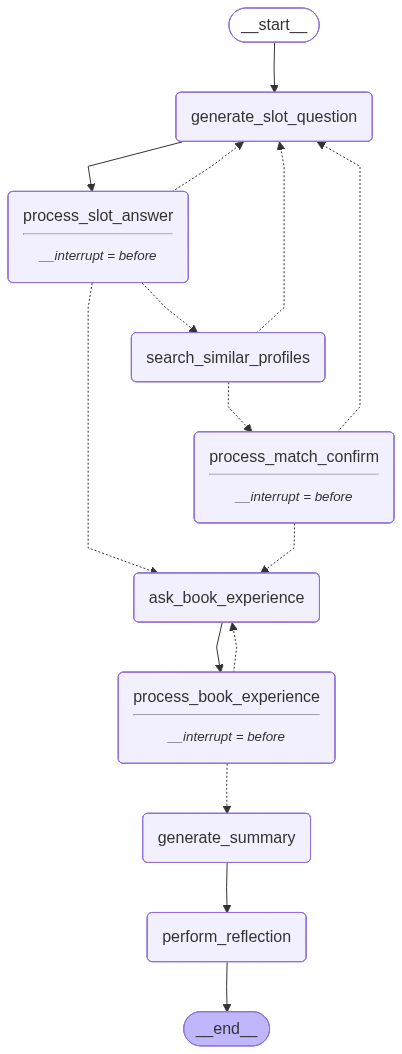

📚 도서 큐레이션 프로파일링 시스템
세션 ID: feb3e5bb
종료하려면 'quit' 또는 'exit'를 입력하세요.

🤖 큐레이터: 최근에 책을 읽고 싶어하는 이유가 무엇인지 궁금해요. 혹시 새로운 지식을 쌓고 싶으신 건가요, 아니면 다른 재미를 찾고 계신 건지요?

👤 사용자: Agentic AI에 대해서 공부하고 싶어

🤖 큐레이터: 안녕하세요! 이전에 바쁜 일상 속에서 판타지 소설을 찾아보셨던 기록이 있습니다. "테메레르"와 같은 흥미로운 세계관을 가진 가벼운 읽을거리를 원하셨죠. 이번에도 비슷한 종류의 책을 찾고 계신가요? (yes/no)

👤 사용자: no

🤖 큐레이터: 그렇군요! 인공지능에 대한 깊이 있는 지식을 쌓고 싶으신 것 같은데요, 그러면 책을 읽을 때 어떤 스타일을 선호하시나요? 예를 들어, 좀 더 깊이 있는 분석이 담긴 책을 좋아하시나요, 아니면 빠르게 읽을 수 있는 책을 선호하시나요?

👤 사용자: 공부를 위한 거니까 깊이 있는 분석이 담긴 책이 좋아

🤖 큐레이터: 그렇다면, 깊이 있는 분석을 담고 있는 인공지능 관련 책을 찾고 계신 것 같아요. 혹시 복잡한 이론이나 수학적인 내용이 많이 포함된 책도 괜찮으신가요, 아니면 조금 더 접근하기 쉬운 난이도의 책을 선호하시나요?

👤 사용자: 복잡한 내용이 포함되있으면 더욱 좋아

🤖 큐레이터: 최근에 읽었던 인공지능 관련 책 중에서 깊이 있는 분석이 담긴 책이 있다면, 어떤 책이었는지 알려주실 수 있나요? 그리고 그 책에서 어떤 점이 좋았는지 간단히 소감도 함께 말씀해 주시면 좋겠습니다.

👤 사용자: 자연어 처리와 컴퓨터비전 심층학습 이라는 책을 가지고 LLM에 대해 공부한 적이 있어. 참고할 수 있는 코드가 상세히 적혀있어서 좋았는데, 이론 내용이 부족해서 아쉬웠어

🤖 큐레이터: 프로필 분석이 완료되었습니다!

📋 요약: 사용자는 인공지능 분야에 대한 깊이 있는 지식을 쌓기 위해 복잡한 이론과 분석이 담긴 책을 원하고 있습니다. 이전에 읽었던 "자연어 처리와 컴퓨터비전 심층학습"

In [ ]:
# """메인 실행 파일 — interrupt_before 패턴 기반 대화 루프.

# 흐름:
#   1. ainvoke(initial_state) → question 노드 실행 → process 노드 직전에서 interrupt
#   2. 사용자 입력 → update_state로 메시지 주입
#   3. ainvoke(None) → process 노드부터 resume → 다음 question → 다시 interrupt
#   4. 반복

# 실행:
#     python main.py

# 환경 변수:
#     OPENAI_API_KEY : OpenAI API 키
#     CHROMA_DB_PATH : ChromaDB 저장 경로 (기본: ./chroma_db)
# """

# from __future__ import annotations

# import asyncio
# import uuid
# from typing import Any

# from langchain_core.messages import AIMessage, HumanMessage
# from langchain_openai import ChatOpenAI
# from langgraph.checkpoint.memory import MemorySaver

# #from db import MemoryStore
# #from graph import compile_graph
# #from models import BookExperience, Phase, UserProfile
# #from state import GraphState
# from IPython.display import Image, display

# def create_initial_state(session_id: str) -> dict[str, Any]:
#     """새 세션의 초기 상태를 생성한다."""
#     return {
#         "messages": [],
#         "session_id": session_id,
#         "phase": Phase.SLOT_FILLING,
#         "turn_count": 0,
#         "user_profile": UserProfile(),
#         "current_slot": "reading_goal",
#         "similar_profiles": None,
#         "matched_profile_id": None,
#         "book_experiences": [],
#         "asked_book_experience": False,
#         "summary": "",
#         "reflection": "",
#         "links": [],
#         "ai_response": "",
#     }


# def _extract_ai_responses(state: dict[str, Any]) -> list[str]:
#     """상태의 messages에서 마지막 사용자 메시지 이후의 AI 메시지들을 추출."""
#     messages = state.get("messages", [])
#     responses = []
#     # 역순으로 순회하며 마지막 HumanMessage 이전의 AI 메시지들 수집
#     for msg in reversed(messages):
#         if isinstance(msg, HumanMessage) or getattr(msg, "type", None) == "human":
#             break
#         if isinstance(msg, AIMessage) or getattr(msg, "type", None) == "ai":
#             responses.append(msg.content)
#     responses.reverse()
#     return responses


# def _print_final_profile(state: dict[str, Any]):
#     """최종 프로필 정보를 출력한다."""
#     profile: UserProfile = state.get("user_profile", UserProfile())
#     experiences: list[BookExperience] = state.get("book_experiences", [])
#     summary: str = state.get("summary", "")
#     reflection: str = state.get("reflection", "")

#     print("\n📋 사용자 프로필:")
#     for name, info in profile.to_display_dict().items():
#         status_icon = {"filled": "✅", "unclear": "❓", "empty": "⬜"}
#         icon = status_icon.get(info["status"], "⬜")
#         print(f"  {icon} {name}: {info['value'] or '(없음)'} [{info['status']}]")

#     if experiences:
#         print("\n📖 독서 경험:")
#         for exp in experiences:
#             print(f"  - {exp.book_name}: {exp.impression} {exp.context}")

#     print(f"\n📝 요약: {summary}")
#     print(f"\n💡 인사이트: {reflection}")


# async def run_conversation():
#     """interrupt_before 패턴 기반 대화 루프."""

#     # ── 의존성 초기화 ──
#     llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
#     memory_store = MemoryStore(persist_directory="./chroma_db")
#     checkpointer = MemorySaver()

#     # ── 그래프 컴파일 ──
#     app = compile_graph(llm, memory_store, checkpointer=checkpointer)
#     display(Image(app.get_graph().draw_mermaid_png()))

#     # ── 세션 시작 ──
#     session_id = str(uuid.uuid4())[:8]
#     thread_id = f"thread_{session_id}"
#     config = {"configurable": {"thread_id": thread_id}}

#     print("=" * 60)
#     print("📚 도서 큐레이션 프로파일링 시스템")
#     print("=" * 60)
#     print(f"세션 ID: {session_id}")
#     print("종료하려면 'quit' 또는 'exit'를 입력하세요.\n")

#     # ── 1단계: 초기 실행 ──
#     # generate_slot_question 실행 → process_slot_answer 직전에서 interrupt
#     result = await app.ainvoke(create_initial_state(session_id), config=config)

#     # AI 응답 출력
#     for resp in _extract_ai_responses(result):
#         print(f"🤖 큐레이터: {resp}\n")

#     # ── 2단계: 대화 루프 ──
#     while True:
#         user_input = input("👤 사용자: ").strip()
#         if not user_input:
#             continue
#         if user_input.lower() in ("quit", "exit", "종료"):
#             print("\n세션을 종료합니다. 감사합니다!")
#             break

#         # 사용자 메시지를 상태에 주입
#         app.update_state(
#             config,
#             {"messages": [HumanMessage(content=user_input)]},
#         )

#         # interrupt 지점에서 resume → process 노드 실행 → 다음 question → 다시 interrupt (또는 END)
#         result = await app.ainvoke(None, config=config)

#         # AI 응답 출력
#         for resp in _extract_ai_responses(result):
#             print(f"\n🤖 큐레이터: {resp}\n")

#         # 완료 체크 (perform_reflection → END 도달 시 interrupt 없이 완료됨)
#         snapshot = app.get_state(config)
#         is_done = snapshot.next == ()  # 다음 실행할 노드가 없으면 그래프 완료
#         if is_done:
#             print("\n" + "=" * 60)
#             print("✅ 프로파일링 완료!")
#             print("=" * 60)
#             _print_final_profile(snapshot.values)
#             break


# if __name__ == "__main__":
#     #asyncio.run(run_conversation())
#     await run_conversation()

## Chromadb에 저장된 session memory 확인

In [ ]:
# import chromadb
# persist_directory = "./chroma_db"
# client = chromadb.PersistentClient(path=persist_directory)

# collections = client.list_collections()

# for c in collections:
#     print(c.name)

memory_links
session_memories


In [ ]:
# collection = client.get_collection("session_memories")

# results = collection.get()

# for i in range(len(results["ids"])):
#     print("=" * 50)
#     print("ID:", results["ids"][i])

#     if results["metadatas"]:
#         print("META:", results["metadatas"][i])

#     if results["documents"]:
#         print("DOC:", results["documents"][i])

ID: 67046a4b
META: {'summary': '사용자는 직장에서 바쁘고 지친 상태에서 생각을 다른 곳으로 전환하고 싶어하며, 판타지 소설에 관심을 가지고 있습니다. 빠르게 읽는 스타일을 선호하고, 가벼운 읽을 거리를 원합니다. 이전에 읽은 "테메레르"처럼 흥미로운 세계관을 가진 판타지 소설을 찾고 있습니다. 이러한 정보를 바탕으로, 사용자의 요구에 맞는 책을 추천할 수 있을 것입니다.', 'timestamp': '2026-06-05T14:47:55.343747', 'profile_json': '{"reading_goal":{"value":"생각을 다른 곳으로 전환하고 싶다","status":"filled","retry_count":0,"MAX_RETRIES":3},"preferred_genre":{"value":"판타지 소설","status":"filled","retry_count":0,"MAX_RETRIES":3},"reading_style":{"value":"빠르게 읽는게 좋아","status":"filled","retry_count":0,"MAX_RETRIES":3},"difficulty_level":{"value":"가벼운 읽을 거리","status":"filled","retry_count":0,"MAX_RETRIES":3},"current_context":{"value":"직장에서 바쁘고 지친 상태","status":"filled","retry_count":0,"MAX_RETRIES":3}}', 'reflection': '사용자는 바쁜 일상 속에서 빠르게 읽을 수 있는 판타지 소설을 통해 생각을 전환하고자 하며, 이전에 경험한 흥미로운 세계관을 찾고 있다. 이러한 경향은 판타지 장르에 대한 지속적인 선호를 나타내며, 가벼운 읽거리를 중시하는 현재의 독서 스타일과 연결된다. 또한, 사용자는 다른 장르에서도 유사한 스타일의 책을 찾을 가능성이 있다.', 'session_id': '67046a4b', 'experiences_json': '[{"b

In [ ]:
# print(results.keys())

dict_keys(['ids', 'embeddings', 'documents', 'uris', 'included', 'data', 'metadatas'])


In [ ]:
# results['documents']

['사용자가 현재 왜 책을 읽고 싶어하는지 (동기/목적): 생각을 다른 곳으로 전환하고 싶다 | 사용자가 현재 관심을 가지는 장르나 분야: 판타지 소설 | 사용자가 어떤 스타일의 독서를 선호하는지 (깊이, 속도, 형식 등): 빠르게 읽는게 좋아 | 사용자가 선호하는 책의 난이도: 가벼운 읽을 거리 | 사용자의 현재 상황이나 감정 상태: 직장에서 바쁘고 지친 상태 | 요약: 사용자는 직장에서 바쁘고 지친 상태에서 생각을 다른 곳으로 전환하고 싶어하며, 판타지 소설에 관심을 가지고 있습니다. 빠르게 읽는 스타일을 선호하고, 가벼운 읽을 거리를 원합니다. 이전에 읽은 "테메레르"처럼 흥미로운 세계관을 가진 판타지 소설을 찾고 있습니다. 이러한 정보를 바탕으로, 사용자의 요구에 맞는 책을 추천할 수 있을 것입니다. | 인사이트: 사용자는 바쁜 일상 속에서 빠르게 읽을 수 있는 판타지 소설을 통해 생각을 전환하고자 하며, 이전에 경험한 흥미로운 세계관을 찾고 있다. 이러한 경향은 판타지 장르에 대한 지속적인 선호를 나타내며, 가벼운 읽거리를 중시하는 현재의 독서 스타일과 연결된다. 또한, 사용자는 다른 장르에서도 유사한 스타일의 책을 찾을 가능성이 있다. | 독서경험: 테메레르 - 1차 세계대전을 배경으로 용이 존재하는 세계관이 흥미로웠어.',
 '사용자가 현재 왜 책을 읽고 싶어하는지 (동기/목적): 생각을 다른 곳으로 전환하고 싶다 | 사용자가 현재 관심을 가지는 장르나 분야: 판타지 소설 | 사용자가 어떤 스타일의 독서를 선호하는지 (깊이, 속도, 형식 등): 빠르게 읽는게 좋아 | 사용자가 선호하는 책의 난이도: 가벼운 읽을 거리 | 사용자의 현재 상황이나 감정 상태: 직장에서 바쁘고 지친 상태 | 요약: 사용자는 바쁜 직장 생활로 인해 스트레스를 해소하고 싶어하며, 판타지 소설을 통해 생각을 전환하고자 합니다. 이전에 읽었던 "테메레르"와 "해리포터"처럼 흥미로운 세계관과 가벼운 읽을 거리를 선호하며, 빠르게 읽을 수 있는 책을 찾고 있습니다. 이러한 요구를 

In [ ]:
# results['metadatas']

[{'summary': '사용자는 직장에서 바쁘고 지친 상태에서 생각을 다른 곳으로 전환하고 싶어하며, 판타지 소설에 관심을 가지고 있습니다. 빠르게 읽는 스타일을 선호하고, 가벼운 읽을 거리를 원합니다. 이전에 읽은 "테메레르"처럼 흥미로운 세계관을 가진 판타지 소설을 찾고 있습니다. 이러한 정보를 바탕으로, 사용자의 요구에 맞는 책을 추천할 수 있을 것입니다.',
  'timestamp': '2026-06-05T14:47:55.343747',
  'profile_json': '{"reading_goal":{"value":"생각을 다른 곳으로 전환하고 싶다","status":"filled","retry_count":0,"MAX_RETRIES":3},"preferred_genre":{"value":"판타지 소설","status":"filled","retry_count":0,"MAX_RETRIES":3},"reading_style":{"value":"빠르게 읽는게 좋아","status":"filled","retry_count":0,"MAX_RETRIES":3},"difficulty_level":{"value":"가벼운 읽을 거리","status":"filled","retry_count":0,"MAX_RETRIES":3},"current_context":{"value":"직장에서 바쁘고 지친 상태","status":"filled","retry_count":0,"MAX_RETRIES":3}}',
  'reflection': '사용자는 바쁜 일상 속에서 빠르게 읽을 수 있는 판타지 소설을 통해 생각을 전환하고자 하며, 이전에 경험한 흥미로운 세계관을 찾고 있다. 이러한 경향은 판타지 장르에 대한 지속적인 선호를 나타내며, 가벼운 읽거리를 중시하는 현재의 독서 스타일과 연결된다. 또한, 사용자는 다른 장르에서도 유사한 스타일의 책을 찾을 가능성이 있다.',
  'session_id': '67046a4b',
  'experiences_json': '[{"book_name

In [ ]:
# results['metadatas'][0]['summary']

'사용자는 직장에서 바쁘고 지친 상태에서 생각을 다른 곳으로 전환하고 싶어하며, 판타지 소설에 관심을 가지고 있습니다. 빠르게 읽는 스타일을 선호하고, 가벼운 읽을 거리를 원합니다. 이전에 읽은 "테메레르"처럼 흥미로운 세계관을 가진 판타지 소설을 찾고 있습니다. 이러한 정보를 바탕으로, 사용자의 요구에 맞는 책을 추천할 수 있을 것입니다.'

In [ ]:
# results['metadatas'][0]['reflection']

'사용자는 바쁜 일상 속에서 빠르게 읽을 수 있는 판타지 소설을 통해 생각을 전환하고자 하며, 이전에 경험한 흥미로운 세계관을 찾고 있다. 이러한 경향은 판타지 장르에 대한 지속적인 선호를 나타내며, 가벼운 읽거리를 중시하는 현재의 독서 스타일과 연결된다. 또한, 사용자는 다른 장르에서도 유사한 스타일의 책을 찾을 가능성이 있다.'

In [ ]:
# results['metadatas'][1]['summary']

'사용자는 바쁜 직장 생활로 인해 스트레스를 해소하고 싶어하며, 판타지 소설을 통해 생각을 전환하고자 합니다. 이전에 읽었던 "테메레르"와 "해리포터"처럼 흥미로운 세계관과 가벼운 읽을 거리를 선호하며, 빠르게 읽을 수 있는 책을 찾고 있습니다. 이러한 요구를 바탕으로, 사용자는 몰입감 있는 판타지 소설을 원하고 있습니다.'

In [ ]:
# results['metadatas'][1]['reflection']

'사용자는 바쁜 일상 속에서 스트레스를 해소하기 위해 가벼운 판타지 소설을 빠르게 읽고자 하며, 흥미로운 세계관을 찾고 있습니다. 이전의 독서 경험은 현재의 요구를 반영하며, 이러한 경향은 판타지 장르에 대한 지속적인 선호를 나타냅니다. 사용자는 다른 장르에서도 유사한 스타일의 책을 탐색할 가능성이 높습니다.'

## 추천 도서를 검색하기 위한 Query: user_profile_query

In [ ]:
# session_idx = 0 # session memory index
# user_profile_query = results['metadatas'][session_idx]['summary'] + ' ' + results['metadatas'][session_idx]['reflection']
# print(user_profile_query)

사용자는 직장에서 바쁘고 지친 상태에서 생각을 다른 곳으로 전환하고 싶어하며, 판타지 소설에 관심을 가지고 있습니다. 빠르게 읽는 스타일을 선호하고, 가벼운 읽을 거리를 원합니다. 이전에 읽은 "테메레르"처럼 흥미로운 세계관을 가진 판타지 소설을 찾고 있습니다. 이러한 정보를 바탕으로, 사용자의 요구에 맞는 책을 추천할 수 있을 것입니다. 사용자는 바쁜 일상 속에서 빠르게 읽을 수 있는 판타지 소설을 통해 생각을 전환하고자 하며, 이전에 경험한 흥미로운 세계관을 찾고 있다. 이러한 경향은 판타지 장르에 대한 지속적인 선호를 나타내며, 가벼운 읽거리를 중시하는 현재의 독서 스타일과 연결된다. 또한, 사용자는 다른 장르에서도 유사한 스타일의 책을 찾을 가능성이 있다.
